# Stochastic Processes in Physics and Finance

This project studies two fundamental Stochastic Process families and shows how the same mathematics appear in both Physics and Finance.

| Process family | Physics interpretation | Finance interpretation |
|---|---|---|
| Ornstein-Uhlenbeck (OU) | Brownian velocity with friction and random force | Vasicek short-rate model |
| Geometric Brownian Motion (GBM) | Overdamped particle in a constant force field | Stock-price GBM and Black-Scholes pricing |

The main numerical method used is Monte Carlo simulation through the Euler-Maruyama Algorithm. The references used in this project are:

1. D. T. Gillespie, “The mathematics of Brownian motion and Johnson noise,” *Am. J. Phys.* **64**, 225 (1996)
2. C. W. Gardiner, *Handbook of Stochastic Methods: for Physics, Chemistry and the Natural Sciences*, Springer
3. MIT OpenCourseWare, *18.642 Topics in Mathematics with Applications in Finance*, Fall 2024, Lecture Notes

## 1. Itô Calculus and Stochastic Differential Equations

A one-dimensional Itô Stochastic Differential Equation has the form

$$
dX_t = a(X_t,\,t)\,dt + b(X_t,\,t)\,dW_t,
$$

where $W_t$ is a Wiener process. The term $a(X_t,\,t)$ is the drift and $b(X_t,\,t)$ is the diffusion coefficient. The integral form is

$$
X_t = X_{t_0} + \int_{t_0}^t a(X_s,\,s)\,ds + \int_{t_0}^t b(X_s,\,s)\,dW_s.
$$

The Itô integral is not an ordinary Riemann integral, and its calculus differs from classical calculus.
The formal rule

$$
(dW_t)^2 = dt
$$

is the key heuristic signal that second-order terms in $dW_t$ survive.

### Itô's lemma

If $X_t$ satisfies

$$
dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t,
$$

and $f(x)$ is sufficiently smooth, then the differential of $f(X_t)$ satisfies, ignoring terms of $dt$ of order higher than 1,

$$
df(X_t)
=
\left(
a(X_t,t)\,\partial_x f + \frac{1}{2}b^2(X_t,t)\,\partial_x^2 f
\right)dt
+
b(X_t,t)\,\partial_x f\,dW_t.
$$

This is the continuous-time chain rule of Stochastic Calculus.


### PDE version of an SDE

The transition probability density is written as $p(x,t|x_0,t_0)$, where $x_0$ is the state at the initial time $t_0$, and $x$ is the state at the later time $t$. For the forward transition problem, $t_0$ may be any real number, but the density is evolved for $t \geq t_0$. The forward Fokker-Planck PDE evolves the density with respect to the final variables $(x,t)$:

$$
\frac{\partial}{\partial t}p(x,t|x_0,t_0)
=
-\frac{\partial}{\partial x}\left[a(x,t)p(x,t|x_0,t_0)\right]
+
\frac{1}{2}\frac{\partial^2}{\partial x^2}\left[b^2(x,t)p(x,t|x_0,t_0)\right],
\quad t>t_0.
$$

The backward Fokker-Planck PDE evolves the same transition density with respect to the initial variables $(x_0,t_0)$:

$$
-\frac{\partial}{\partial t_0}p(x,t|x_0,t_0)
=
a(x_0,t_0)\frac{\partial}{\partial x_0}p(x,t|x_0,t_0)
+
\frac{1}{2}b^2(x_0,t_0)\frac{\partial^2}{\partial x_0^2}p(x,t|x_0,t_0),
\quad t>t_0.
$$

The initial (or terminal) condition is

$$
p(x,t_0|x_0,t_0)=\delta(x-x_0).
$$

Thus, the forward equation differentiates with respect to the final variables $(x,t)$, while the backward equation differentiates with respect to the initial variables $(x_0,t_0)$. Since we solve these PDEs for a class of functions with a given initial/terminal condition, their solution is exactly the same unique probability density function that corresponds to the given SDE. In Finance, pricing PDEs are backward equations, usually with an additional discounting term.


### Pseudocode: Euler-Maruyama simulation of a generic Itô Process

$$
\begin{aligned}
&\textbf{SDE } \Delta X_n = a(X_n,t_n)\Delta t + b(X_n,t_n)\Delta W_n \\
&\textbf{Choose } \Delta t = (t-t_0)/N,\quad t_n=t_0+n\,\Delta t,\\
&Z_n\sim\mathcal{N}(0,1)\text{ independently}\\
&\Delta W_n = \sqrt{\Delta t}\,Z_n\\
&X_{n+1} = X_n + a(X_n,t_n)\Delta t + b(X_n,t_n)\Delta W_n
\end{aligned}
$$

This is the fundamental numeric algorithm used for the Monte Carlo simulation of an SDE.


### Imports and numerical setup

We use NumPy for simulations, Matplotlib for plots, Pandas for compact summaries, and SciPy for the standard normal distribution functions used in the Black-Scholes formula.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.set_printoptions(precision=6, suppress=True)
pd.options.display.float_format = "{:,.6f}".format

## 2.1 The Ornstein-Uhlenbeck (OU) process

The general OU SDE is

$$
dX_t=-\lambda(X_t-\theta)\,dt+\eta\,dW_t
$$

with initial condition

$$
X_{t_0}=x_0.
$$

In the general finite-time theory, we allow

$$
x_0,\lambda,\theta,\eta\in\mathbb{R}.
$$

The usual stable, mean-reverting OU process corresponds to $\lambda>0$. If $\lambda<0$, the SDE is still solvable for finite times, but the process is unstable and has no stationary distribution. If $\lambda=0$, the process becomes Brownian motion with constant diffusion. The sign of $\eta$ has no distributional significance due to the Gaussian factor $dW_t$. In the notation of the general Itô SDE,

$$
a(x,t)=-\lambda(x-\theta),
\qquad
b(x,t)=\eta.
$$

### Analytical solution through the SDE

For an initial condition $X_{t_0}=x_0$ and $t\geq t_0$, the analytical solution is

$$
X_t=
\theta+(x_0-\theta)e^{-\lambda(t-t_0)}
+
\eta\int_{t_0}^{t}e^{-\lambda(t-s)}\,dW_s.
$$

Therefore, $X_t$ is Gaussian whenever the noise is non-degenerate. More precisely,

$$
X_t
\sim
\mathcal{N}
\left(
m(t,t_0),
s^2(t,t_0)
\right),
$$

where

$$
m(t,t_0)
=
\theta+(x_0-\theta)e^{-\lambda(t-t_0)}
$$

and

$$
s^2(t,t_0)
=
\begin{cases}
\dfrac{\eta^2}{2\lambda}
\left(1-e^{-2\lambda(t-t_0)}\right),
& \lambda\neq 0, \\[8pt]
\eta^2(t-t_0),
& \lambda=0.
\end{cases}
$$

Hence, the transition density is

$$
p(x,t|x_0,t_0)
=
\frac{1}{\sqrt{2\pi s^2(t,t_0)}}
\exp\left[
-\frac{(x-m(t,t_0))^2}{2s^2(t,t_0)}
\right], \quad t>t_0
$$

and, at the initial time,

$$
p(x,t_0|x_0,t_0)=\delta(x-x_0).
$$

If $\eta=0$, the process is deterministic and the transition distribution is a delta distribution concentrated at the deterministic solution $m(t,t_0)$.


### Fokker-Planck PDEs for the OU process

For

$$
dX_t=-\lambda(X_t-\theta)\,dt+\eta\,dW_t,
$$

the forward Fokker-Planck PDE is

$$
\frac{\partial}{\partial t}p(x,t|x_0,t_0)
=
\lambda
\frac{\partial}{\partial x}
\left[
(x-\theta)p(x,t|x_0,t_0)
\right]
+
\frac{\eta^2}{2}
\frac{\partial^2}{\partial x^2}
p(x,t|x_0,t_0),
\quad t>t_0.
$$

The backward Fokker-Planck PDE is

$$
-\frac{\partial}{\partial t_0}p(x,t|x_0,t_0)
=
-\lambda(x_0-\theta)
\frac{\partial}{\partial x_0}p(x,t|x_0,t_0)
+
\frac{\eta^2}{2}
\frac{\partial^2}{\partial x_0^2}p(x,t|x_0,t_0),
\quad t>t_0.
$$

The initial (or terminal) condition is

$$
p(x,t_0|x_0,t_0)=\delta(x-x_0).
$$

To solve the forward OU PDE, we use separation of variables/Fourier transforms and the method of characteristics. The result is the Gaussian transition density

$$
p(x,t|x_0,t_0)
=
\frac{1}{\sqrt{2\pi s^2(t,t_0)}}
\exp\left[
-\frac{(x-m(t,t_0))^2}{2s^2(t,t_0)}
\right],
\quad t>t_0,
$$

where

$$
m(t,t_0)
=
\theta+(x_0-\theta)e^{-\lambda(t-t_0)}
$$

and

$$
s^2(t,t_0)
=
\begin{cases}
\dfrac{\eta^2}{2\lambda}
\left(1-e^{-2\lambda(t-t_0)}\right),
& \lambda\neq 0, \\[8pt]
\eta^2(t-t_0),
& \lambda=0.
\end{cases}
$$

Equivalently,

$$
X_t
\sim
\mathcal{N}\left(m(t,t_0),s^2(t,t_0)\right).
$$

At $t=t_0$, the transition distribution is the delta distribution

$$
p(x,t_0|x_0,t_0)=\delta(x-x_0).
$$

If $\eta=0$, the OU solution is deterministic and the transition distribution is a delta distribution centered at $m(t,t_0)$. The forward OU PDE solution is unique for the fixed initial condition by the standard Uniqueness Theorem for the forward Fokker-Planck PDE.


### Pseudocode: Euler-Maruyama simulation of the OU process

$$
\begin{aligned}
&\textbf{SDE } \Delta X_t=-\lambda(X_t-\theta)\Delta t+\eta\,\Delta W_t\\
&\textbf{Choose } \Delta t=(t-t_0)/N,\quad t_n=t_0+n\,\Delta t\\
&Z_n\sim\mathcal{N}(0,1)\text{ independently}\\
&\Delta W_n = \sqrt{\Delta t}\,Z_n\\
&X_{n+1}= X_n-\lambda(X_n-\theta)\Delta t+\eta\,\Delta W_n
\end{aligned}
$$

The analytical formulas above are used as benchmarks for the Monte Carlo simulation.

In [2]:
def simulate_ou_euler(x0, t, t0, theta, lam, eta, n_steps, n_paths, seed=123):
    """
    Euler-Maruyama simulation of the OU-type SDE:
    dX_t = -lam*(X_t - theta) dt + eta dW_t.

    The parameters x0, theta, lam, and eta are allowed to be real.
    The usual stable mean-reverting OU case corresponds to lam > 0.
    """
    if t < t0:
        raise ValueError("t must be greater than or equal to t0 for the forward simulation.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")

    rng = np.random.default_rng(seed)
    dt = (t - t0) / n_steps
    sqrt_dt = np.sqrt(dt)
    time_grid = np.linspace(t0, t, n_steps + 1)
    x_paths = np.empty((n_steps + 1, n_paths))
    x_paths[0, :] = x0

    for n in range(n_steps):
        Z = rng.standard_normal(n_paths)
        dW = sqrt_dt * Z
        x_paths[n + 1, :] = x_paths[n, :] - lam * (x_paths[n, :] - theta) * dt + eta * dW

    return time_grid, x_paths


def ou_mean(x0, t, t0, theta, lam):
    tau = np.asarray(t) - t0
    if np.any(tau < 0):
        raise ValueError("The forward solution requires t >= t0.")
    return theta + (x0 - theta) * np.exp(-lam * tau)


def ou_variance(t, t0, lam, eta):
    tau = np.asarray(t) - t0
    if np.any(tau < 0):
        raise ValueError("The forward solution requires t >= t0.")
    if np.isclose(lam, 0.0):
        return eta**2 * tau
    return (eta**2 / (2.0 * lam)) * (1.0 - np.exp(-2.0 * lam * tau))


def ou_density(x_grid, x0, t, t0, theta, lam, eta):
    """Analytical OU transition density p(x,t | x0,t0), for t > t0."""
    if t < t0:
        raise ValueError("The forward transition law requires t >= t0.")

    mean = ou_mean(x0, t, t0, theta, lam)
    var = ou_variance(t, t0, lam, eta)

    return (1.0 / np.sqrt(2.0 * np.pi * var)) * np.exp(-0.5 * (x_grid - mean)**2 / var)


In [3]:
# Generic OU parameters
x0 = 1.5
t_ou_final = 4.0
t0_ou = 0.0
theta = 0.2
lam = 1.3
eta = 0.7
n_steps_ou = 500
n_paths_ou = 10_000

t_ou, x_paths = simulate_ou_euler(
    x0=x0,
    t=t_ou_final,
    t0=t0_ou,
    theta=theta,
    lam=lam,
    eta=eta,
    n_steps=n_steps_ou,
    n_paths=n_paths_ou,
    seed=101,
)

mean_ou_theory = ou_mean(x0, t_ou, t0_ou, theta, lam)
var_ou_theory = ou_variance(t_ou, t0_ou, lam, eta)
mean_ou_mc = x_paths.mean(axis=1)
var_ou_mc = x_paths.var(axis=1, ddof=1)

summary_ou_general = pd.DataFrame({"time": [0.5, 1.0, 2.0, 4.0]})
summary_ou_general["MC mean"] = np.interp(summary_ou_general["time"], t_ou, mean_ou_mc)
summary_ou_general["Theory mean"] = np.interp(summary_ou_general["time"], t_ou, mean_ou_theory)
summary_ou_general["MC variance"] = np.interp(summary_ou_general["time"], t_ou, var_ou_mc)
summary_ou_general["Theory variance"] = np.interp(summary_ou_general["time"], t_ou, var_ou_theory)
summary_ou_general


,time,MC mean,Theory mean,MC variance,Theory variance
0,0.500000,0.874241,0.878669,0.136478,0.137097
1,1.000000,0.550544,0.554291,0.173536,0.174464
2,2.000000,0.289824,0.296556,0.188654,0.187422
3,4.000000,0.200745,0.207172,0.184628,0.188456


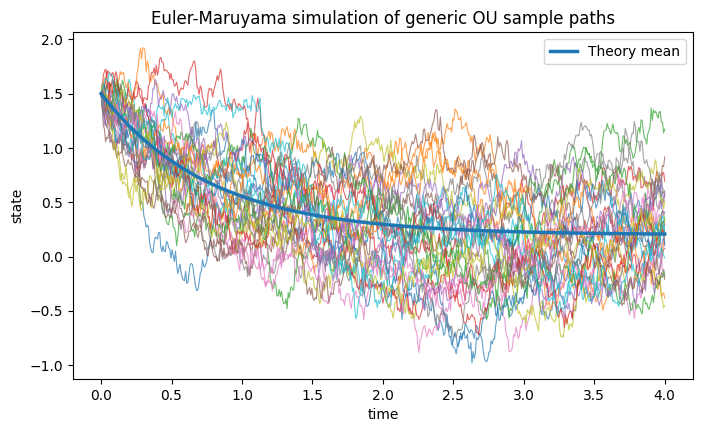

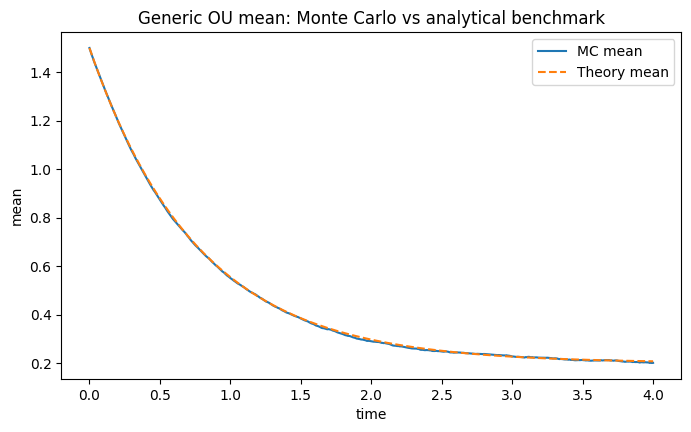

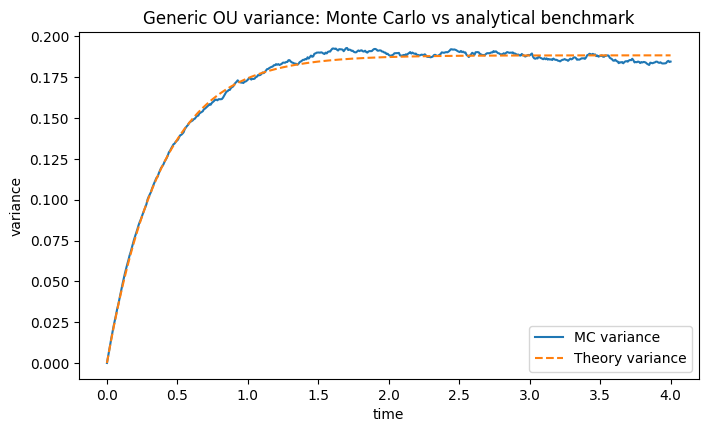

In [4]:
plt.figure(figsize=(8, 4.5))
plt.plot(t_ou, x_paths[:, :30], linewidth=0.8, alpha=0.7)
plt.plot(t_ou, mean_ou_theory, linewidth=2.5, label="Theory mean")
plt.xlabel("time")
plt.ylabel("state")
plt.title("Euler-Maruyama simulation of generic OU sample paths")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(t_ou, mean_ou_mc, label="MC mean")
plt.plot(t_ou, mean_ou_theory, linestyle="--", label="Theory mean")
plt.xlabel("time")
plt.ylabel("mean")
plt.title("Generic OU mean: Monte Carlo vs analytical benchmark")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(t_ou, var_ou_mc, label="MC variance")
plt.plot(t_ou, var_ou_theory, linestyle="--", label="Theory variance")
plt.xlabel("time")
plt.ylabel("variance")
plt.title("Generic OU variance: Monte Carlo vs analytical benchmark")
plt.legend()
plt.show()


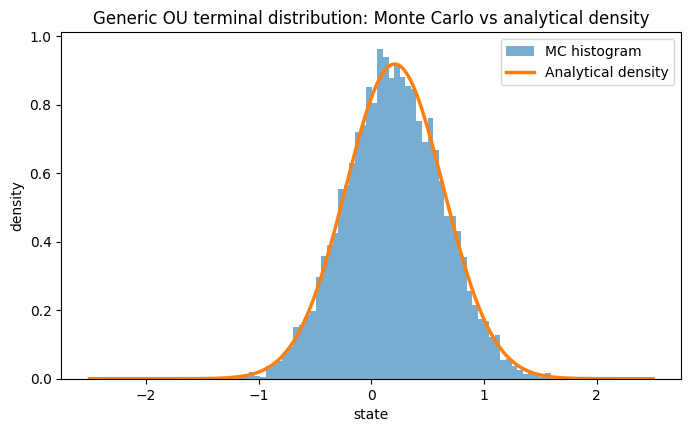

Normalization check over the plotted grid: 1.000000


In [5]:
x_grid = np.linspace(-2.5, 2.5, 800)
t_terminal_ou = t_ou_final
density_ou_terminal = ou_density(x_grid, x0, t_terminal_ou, t0_ou, theta, lam, eta)

plt.figure(figsize=(8, 4.5))
plt.hist(x_paths[-1, :], bins=70, density=True, alpha=0.6, label="MC histogram")
plt.plot(x_grid, density_ou_terminal, linewidth=2.5, label="Analytical density")
plt.xlabel("state")
plt.ylabel("density")
plt.title("Generic OU terminal distribution: Monte Carlo vs analytical density")
plt.legend()
plt.show()

normalization_check_ou = np.trapezoid(density_ou_terminal, x_grid)
print(f"Normalization check over the plotted grid: {normalization_check_ou:.6f}")


## 2.2 The OU process in Physics and Finance

### Physics example: Brownian velocity with friction

A Brownian particle moving inside a fluid experiences friction and random molecular forces. We begin from Newton's 2nd law:

$$
m\frac{dv(t)}{dt}=-\gamma v(t)+R(t).
$$

Define the relaxation time

$$
\tau\equiv\frac{m}{\gamma},
$$

and write the random force in White Noise form as

$$
R(t)=m\sqrt{c}\,\Gamma(t),
$$

where the White Noise function $\Gamma(t)$ is defined informally as

$$
\Gamma(t) \sim \mathcal{N}\left(0,\frac{1}{dt}\right) \equiv \lim_{\Delta t \to 0} \, \mathcal{N}\left(0,\frac{1}{\Delta t}\right).
$$
  
The random variables $\Gamma(t)$ and $\Gamma(t')$ are uncorrelated at different times $t \neq t'$, so we have

$$\qquad
\mathbb{E}[\Gamma(t)\Gamma(t')]=\delta(t-t').
$$

We can also define the Wiener Increment $dW(t)$ of the Wiener Process $W(t)$ as

$$
dW(t)=\Gamma(t)\,dt \sim \mathcal{N}(0,dt)
$$

or, equivalently,

$$
dW(t)=\sqrt{dt}\, N(t),
$$

where $N(t) \sim \mathcal{N}(0,1)$. Thus, we have

$$
\frac{dv(t)}{dt}=-\frac{1}{\tau}v(t)+\sqrt{c}\,\Gamma(t).
$$

Using the informal Itô bookkeeping notation:

$$
dW(t)=\Gamma(t)\,dt,
\qquad
(dW(t))^2=dt,
$$

we obtain an OU SDE

$$
dv(t)=-\frac{1}{\tau}v(t)\,dt+\sqrt{c}\,dW(t).
$$

This is the first Physics-to-Finance bridge: the same OU process will later become the Vasicek model for interest rates.

### Analytical solution of the Physical OU SDE

We will now switch to the more usual Stochastic Process notation, e.g. $v_t\equiv v(t)$, $dW_t\equiv dW(t)$. We will try to solve the physical OU SDE

$$
\boxed{
dv_t=-\frac{1}{\tau}v_t\,dt+\sqrt{c}\,dW_t.
}
$$

This is not a new Stochastic Process calculation. It is the general OU process with the parameter identification

$$
X_t=v_t,
\qquad
\lambda=\frac{1}{\tau},
\qquad
\theta=0,
\qquad
\eta=\sqrt{c}.
$$

Therefore, all mean, variance, density, and simulation formulas are inherited directly from the general O-U solution. For initial (deterministic) velocity $v_0$ the solution is

$$
\boxed{
v_t=v_0e^{-t/\tau}+\sqrt{c}\int_0^t e^{-(t-s)/\tau}\,dW_s.
}
$$

Therefore,

$$
\boxed{
\mathbb{E}[v_t]=v_0e^{-t/\tau}
}
$$

and

$$
\boxed{
\operatorname{Var}(v_t)=\frac{c\tau}{2}\left(1-e^{-2t/\tau}\right).
}
$$

The probability density function of the velocity random variable $v_t$ at time $t$ given that its value is $v_0$ at time $0$ is found to be the Gaussian

$$
p(v,t | v_0,0)
=
\frac{1}{
\sqrt{
\pi c\tau
\left(1-e^{-2t/\tau}\right)
}
}
\exp\left[
-
\frac{
\left(v-v_0e^{-t/\tau}\right)^2
}{
c\tau
\left(1-e^{-2t/\tau}\right)
}
\right].
$$

With the physical normalization

$$
c\tau=\frac{2k_BT}{m},
$$

we get

$$
p(v,t | v_0,0)
=
\sqrt{
\frac{m}{
2\pi k_BT
\left(1-e^{-2t/\tau}\right)
}
}
\exp\left[
-
\frac{m}{2k_BT}
\frac{
\left(v-v_0e^{-t/\tau}\right)^2
}{
1-e^{-2t/\tau}
}
\right].
$$

At the Stationary Limit $t\gg1$ the stationary velocity distribution is the 1D Maxwell--Boltzmann Gaussian.

$$
p(v,t | v_0,0)
=
\sqrt{
\frac{m}{2\pi k_BT}
}
\exp\left(-\frac{mv^2}{2k_BT}\right).
$$

### Finance example: Vasicek interest-rate model

The Vasicek short-rate model is

$$
dr_t=a(b-r_t)\,dt+\sigma_r\,dW_t.
$$

Equivalently,

$$
dr_t=-a(r_t-b)\,dt+\sigma_r\,dW_t.
$$

This is not a new stochastic-process calculation. It is the same general OU process with

$$
X_t=r_t,
\qquad
\lambda=a,
\qquad
\theta=b,
\qquad
\eta=\sigma_r.
$$

Thus, the Vasicek model reuses the OU transition density

$$
p(x,t|x_0,t_0)
$$

with $x=r$ and $x_0=r_0$. The analytical solution, the forward and backward Fokker-Planck equations, and the Euler-Maruyama scheme are already contained in the general OU section.

## 3.1 The Geometric Brownian Motion (GBM) process

The general GBM SDE is

$$
dX_t=\mu X_t\,dt+\sigma X_t\,dW_t
$$

with initial condition

$$
X_{t_0}=x_0.
$$

In the general finite-time theory, we allow

$$
x_0,\mu,\sigma\in\mathbb{R}.
$$

In the notation of the general Itô SDE,

$$
a(x,t)=\mu x,
\qquad
b(x,t)=\sigma x.
$$

Unlike the OU process, the noise amplitude is proportional to the current state. This multiplicative structure is the key feature of GBM. The sign of $\sigma$ has no distributional significance due to the Gaussian factor $dW_t$. The initial value $x_0$ controls the sign of the process: positive initial data produces positive paths, negative initial data produces negative paths, and $x_0=0$ gives the identically zero solution.


### Analytical solution through the SDE

We do not start by defining $\log X_t$, because $X_t$ has not yet been shown to be positive. Instead, we solve the GBM SDE with a stochastic integrating factor. For

$$
dX_t=\mu X_t\,dt+\sigma X_t\,dW_t,
\quad X_{t_0}=x_0,
$$

define

$$
M_t
=
\exp\left[
-\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0)
-\sigma(W_t-W_{t_0})
\right].
$$

By Itô's lemma,

$$
dM_t
=
M_t\left[(-\mu+\sigma^2)\,dt-\sigma\,dW_t\right],
$$

so

$$
dM_t\,X_t
=
-M_t\,dX_t+\sigma^2 M_t\,X_t\,dt
$$

and

$$
dM_t\,dX_t = \sigma^2 M_t\,X_t\,dt.
$$

It is true in general (even for finite differences) that

$$
d(M_t\,X_t)
=
M_t\,dX_t
+
X_t\,dM_t
+dM_t\,dX_t,
$$

therefore,

$$
d(M_tX_t)=0.
$$

Since $M_{t_0}=1$, we obtain

$$
M_tX_t=M_{t_0}X_{t_0}=x_0.
$$

Solving for $X_t$ gives

$$
X_t
=
x_0\exp\left[
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0)
+\sigma(W_t-W_{t_0})
\right], \quad t>t_0.
$$

This formula is valid for any real $x_0$. Since the exponential factor is always positive,

$$
\operatorname{sign}(X_t)=\operatorname{sign}(x_0).
$$

Thus, if $x_0>0$, then $X_t>0$; if $x_0<0$, then $X_t<0$; and if $x_0=0$, then $X_t=0$. Hence, for $X_t$ we have

$$
X_t
\sim
\operatorname{sign}(x_0)\, \operatorname{Lognormal}
\left(
\log|x_0|
+
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0),
\,
\sigma^2(t-t_0)
\right), \quad t \geq t_0.
$$

The mean and variance are

$$
\mathbb{E}[X_t]
=
x_0e^{\mu(t-t_0)},
$$

and

$$
\operatorname{Var}(X_t)
=
x_0^2e^{2\mu(t-t_0)}\left(e^{\sigma^2(t-t_0)}-1\right).
$$


### Forward Fokker-Planck PDE for GBM

For

$$
dX_t=\mu X_t\,dt+\sigma X_t\,dW_t,
$$

the forward Fokker-Planck PDE for $p(x,t|x_0,t_0)$ is

$$
\frac{\partial}{\partial t}p(x,t|x_0,t_0)
=
-\frac{\partial}{\partial x}
\left[
\mu x\,p(x,t|x_0,t_0)
\right]
+
\frac{1}{2}
\frac{\partial^2}{\partial x^2}
\left[
\sigma^2x^2\,p(x,t|x_0,t_0)
\right],
\quad t>t_0.
$$

The backward Fokker-Planck PDE is

$$
-\frac{\partial}{\partial t_0}p(x,t|x_0,t_0)
=
\mu x_0
\frac{\partial}{\partial x_0}p(x,t|x_0,t_0)
+
\frac{1}{2}\sigma^2x_0^2
\frac{\partial^2}{\partial x_0^2}p(x,t|x_0,t_0),
\quad t>t_0.
$$

The initial (or terminal) condition is

$$
p(x,t_0|x_0,t_0)=\delta(x-x_0).
$$

We will try to solve the forward GBM PDE. The point $x=0$ is degenerate because both coefficients vanish there:

$$
\mu x=0,
\quad
\sigma^2x^2=0
\quad
\text{at } x=0.
$$

Therefore, for $x_0\neq0$, the PDE is solved separately on the two open half-lines $x>0$ and $x<0$. On each half-line, the logarithmic variable

$$
y=\log|x|
$$

is smooth. Define the new density function

$$
q(y,t)=|x|p(x,t|x_0,t_0)
$$

or, equivalently,

$$
p(x,t|x_0,t_0)
=
\frac{1}{|x|}q(\log|x|,t).
$$

This is a branch-wise PDE transformation, not a global transformation through $x=0$. Under this transformation, the forward Fokker-Planck GBM PDE becomes

$$
\frac{\partial q}{\partial t}
=
-\left(\mu-\frac{1}{2}\sigma^2\right)
\frac{\partial q}{\partial y}
+
\frac{\sigma^2}{2}
\frac{\partial^2 q}{\partial y^2}.
$$

This is a constant-coefficient drift-diffusion PDE. It is solved by separation of variables/Fourier transform. If the initial point $x_0$ lies on the branch being considered, then

$$
q(y,t_0)=\delta(y-y_0),
\qquad
y_0=\log|x_0|.
$$

If $x_0$ lies on the opposite branch, then the initial condition on that branch is zero, and the branch solution remains zero. Therefore, for $x_0\neq0$, the transition density is

$$
p(x,t|x_0,t_0)
=
\frac{\mathbf{1}_{xx_0>0}}{|x|\sqrt{2\pi\sigma^2(t-t_0)}}
\exp\left[
-
\frac{
\left(
\log\left|\frac{x}{x_0}\right|
-
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0)
\right)^2
}{
2\sigma^2(t-t_0)
}
\right], \quad t>t_0.
$$

The factor $\mathbf{1}_{xx_0>0}$ means that the density is supported on the same half-line as $x_0$. If $x_0>0$, the density is nonzero only for $x>0$. If $x_0<0$, the density is nonzero only for $x<0$. For $x_0=0$, the $\delta(x)$ satisfies both the PDE and the initial condition. By uniqueness of the forward Fokker-Planck PDE with a fixed initial condition,

$$
p(x,t|0,t_0)=\delta(x).
$$

To summarize, $X_t$ satisfies

$$
X_t
\sim
\operatorname{sign}(x_0)\, \operatorname{Lognormal}
\left(
\log|x_0|
+
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0),
\,
\sigma^2(t-t_0)
\right), \quad t \geq t_0.
$$

### Pseudocode: Euler-Maruyama simulation of the GBM process

$$
\begin{aligned}
&\textbf{SDE } \Delta X_n=\mu X_n\,\Delta t+\sigma X_n\,\Delta W_n\\
&\textbf{Choose } \Delta t=(t-t_0)/N,\quad t_n=t_0+n\,\Delta t\\
&Z_n\sim\mathcal{N}(0,1)\text{ independently}\\
&\Delta W_n = \sqrt{\Delta t}\,Z_n\\
&X_{n+1}=X_n+\mu X_n\,\Delta t+\sigma X_n\,\Delta W_n
\end{aligned}
$$

Equivalently,

$$
X_{n+1}=X_n\left(1+\mu\Delta t+\sigma\Delta W_n\right).
$$

The exact GBM solution preserves the sign of $x_0$, but the direct Euler-Maruyama approximation does not necessarily preserve sign, because the multiplier $1+\mu\Delta t+\sigma\Delta W_n$ can be negative. This is a numerical artifact of the direct discretization. The numerical examples below use the usual positive initial value and small time step, so this artifact is very unlikely in the demonstration. The analytical formulas above are used as benchmarks for the Monte Carlo simulation.

In [6]:
def simulate_gbm_euler(x0, t, t0, mu, sigma, n_steps, n_paths, seed=123):
    """
    Euler-Maruyama simulation of the GBM SDE itself:
    dX_t = mu*X_t dt + sigma*X_t dW_t.

    The parameters x0, mu, and sigma are allowed to be real.
    If x0 = 0, the exact solution is identically zero.
    """
    if t < t0:
        raise ValueError("t must be greater than or equal to t0 for the forward simulation.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")

    rng = np.random.default_rng(seed)
    dt = (t - t0) / n_steps
    sqrt_dt = np.sqrt(dt)
    time_grid = np.linspace(t0, t, n_steps + 1)

    x_paths = np.empty((n_steps + 1, n_paths))
    x_paths[0, :] = x0

    for n in range(n_steps):
        Z = rng.standard_normal(n_paths)
        dW = sqrt_dt * Z
        x_paths[n + 1, :] = x_paths[n, :] + mu * x_paths[n, :] * dt + sigma * x_paths[n, :] * dW

    return time_grid, x_paths


def gbm_mean(x0, t, t0, mu):
    tau = np.asarray(t) - t0
    if np.any(tau < 0):
        raise ValueError("The forward solution requires t >= t0.")
    return x0 * np.exp(mu * tau)


def gbm_variance(x0, t, t0, mu, sigma):
    tau = np.asarray(t) - t0
    if np.any(tau < 0):
        raise ValueError("The forward solution requires t >= t0.")
    return x0**2 * np.exp(2.0 * mu * tau) * (np.exp(sigma**2 * tau) - 1.0)


def gbm_density(x_grid, x0, t, t0, mu, sigma):
    """
    Non-degenerate GBM transition density p(x,t | x0,t0) for real x0.

    If x0 > 0, the support is x > 0.
    If x0 < 0, the support is x < 0.
    If x0 = 0 or sigma = 0, the transition distribution is degenerate.
    """
    if t < t0:
        raise ValueError("The forward transition law requires t >= t0.")
    tau = t - t0
    x_grid = np.asarray(x_grid)
    density = np.zeros_like(x_grid, dtype=float)
    support = x_grid * x0 > 0.0

    log_ratio = np.log(np.abs(x_grid[support] / x0))
    mean_log_ratio = (mu - 0.5 * sigma**2) * tau
    var_log = sigma**2 * tau

    density[support] = (
        1.0 / (np.abs(x_grid[support]) * abs(sigma) * np.sqrt(2.0 * np.pi * tau))
        * np.exp(-0.5 * (log_ratio - mean_log_ratio)**2 / var_log)
    )

    return density


In [7]:
# Generic GBM parameters
x0_gbm = 100.0
t_gbm_final = 1.0
t0_gbm = 0.0
mu_gbm = 0.08
sigma_gbm = 0.20
n_steps_gbm = 252
n_paths_gbm = 20_000

t_gbm, x_gbm_paths = simulate_gbm_euler(
    x0=x0_gbm,
    t=t_gbm_final,
    t0=t0_gbm,
    mu=mu_gbm,
    sigma=sigma_gbm,
    n_steps=n_steps_gbm,
    n_paths=n_paths_gbm,
    seed=21,
)

mean_gbm_theory = gbm_mean(x0_gbm, t_gbm, t0_gbm, mu_gbm)
var_gbm_theory = gbm_variance(x0_gbm, t_gbm, t0_gbm, mu_gbm, sigma_gbm)
mean_gbm_mc = x_gbm_paths.mean(axis=1)
var_gbm_mc = x_gbm_paths.var(axis=1, ddof=1)

summary_gbm_general = pd.DataFrame({"time": [0.25, 0.5, 0.75, 1.0]})
summary_gbm_general["MC mean"] = np.interp(summary_gbm_general["time"], t_gbm, mean_gbm_mc)
summary_gbm_general["Theory mean"] = np.interp(summary_gbm_general["time"], t_gbm, mean_gbm_theory)
summary_gbm_general["MC variance"] = np.interp(summary_gbm_general["time"], t_gbm, var_gbm_mc)
summary_gbm_general["Theory variance"] = np.interp(summary_gbm_general["time"], t_gbm, var_gbm_theory)
summary_gbm_general


,time,MC mean,Theory mean,MC variance,Theory variance
0,0.250000,102.006283,102.020134,106.184106,104.603222
1,0.500000,104.016992,104.081077,221.323840,218.838504
2,0.750000,106.172044,106.183655,353.274442,343.373911
3,1.000000,108.401014,108.328707,488.120620,478.918872


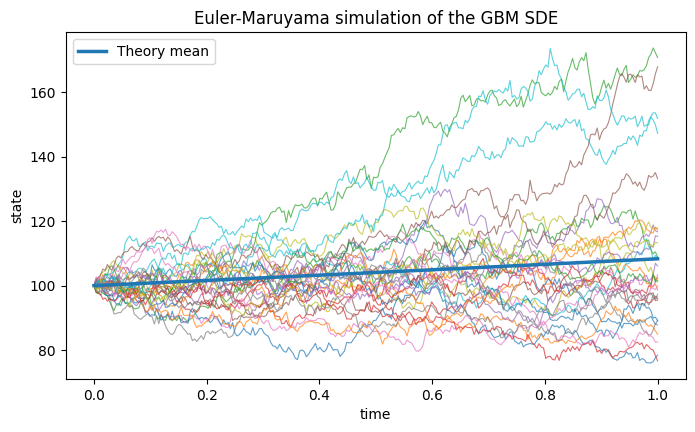

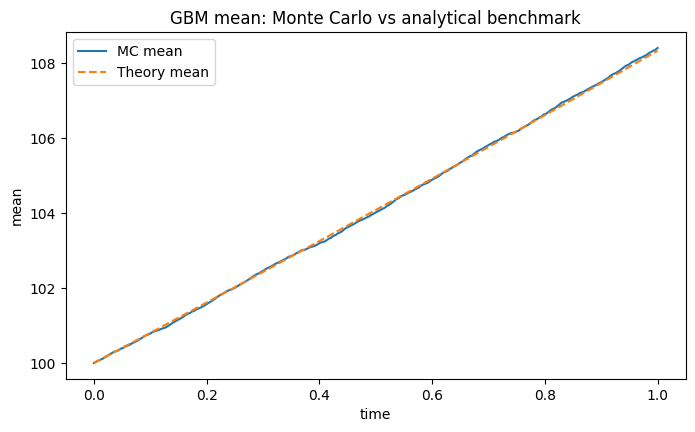

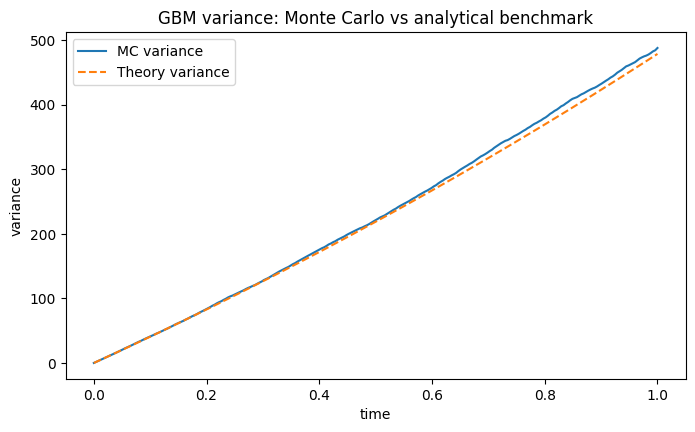

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(t_gbm, x_gbm_paths[:, :30], linewidth=0.8, alpha=0.7)
plt.plot(t_gbm, mean_gbm_theory, linewidth=2.5, label="Theory mean")
plt.xlabel("time")
plt.ylabel("state")
plt.title("Euler-Maruyama simulation of the GBM SDE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(t_gbm, mean_gbm_mc, label="MC mean")
plt.plot(t_gbm, mean_gbm_theory, linestyle="--", label="Theory mean")
plt.xlabel("time")
plt.ylabel("mean")
plt.title("GBM mean: Monte Carlo vs analytical benchmark")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(t_gbm, var_gbm_mc, label="MC variance")
plt.plot(t_gbm, var_gbm_theory, linestyle="--", label="Theory variance")
plt.xlabel("time")
plt.ylabel("variance")
plt.title("GBM variance: Monte Carlo vs analytical benchmark")
plt.legend()
plt.show()

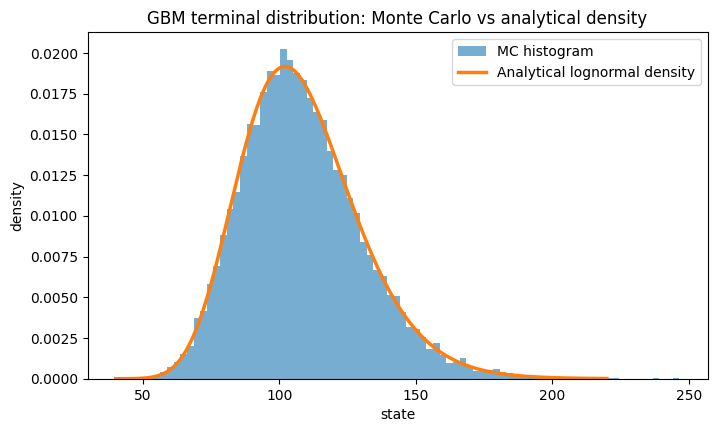

Normalization check over the plotted grid: 0.999864


In [9]:
x_grid_gbm = np.linspace(40.0, 220.0, 1000)
t_terminal_gbm = t_gbm_final
density_gbm_terminal = gbm_density(x_grid_gbm, x0_gbm, t_terminal_gbm, t0_gbm, mu_gbm, sigma_gbm)

plt.figure(figsize=(8, 4.5))
plt.hist(x_gbm_paths[-1, :], bins=80, density=True, alpha=0.6, label="MC histogram")
plt.plot(x_grid_gbm, density_gbm_terminal, linewidth=2.5, label="Analytical lognormal density")
plt.xlabel("state")
plt.ylabel("density")
plt.title("GBM terminal distribution: Monte Carlo vs analytical density")
plt.legend()
plt.show()

normalization_check_gbm = np.trapezoid(density_gbm_terminal, x_grid_gbm)
print(f"Normalization check over the plotted grid: {normalization_check_gbm:.6f}")

## 3.2 Physics and Finance interpretations of the GBM family

The GBM process has now been solved once in its general form. The following examples are therefore only interpretations and parameter mappings. No new stochastic-process solution is needed.

### Physics example: Overdamped particle in a constant force field

Consider the constant force physical process

$$
dx(t)=u\,dt+\sqrt{2D}\,dW(t).
$$

This is the standard drift-diffusion process for an overdamped Brownian particle in a constant force field such as the constant gravitational field near the Earth's surface. The variable $x(t)$ is the natural physical coordinate. The connection with the GBM process appears after exponentiation. Defining

$$
X(t)=e^{x_t}
$$

will give for $X(t)$ the SDE

$$
dX(t)=(u+D) X(t)\,dt +\sqrt{2D} X(t)\,dW(t).
$$

So the physical process $x(t)=\log X(t)$ is the log-space form of a GBM process. Thus the physical constant force process $x(t)$ is related to the GBM process through the transformed variable $X(t)$. In this sense it is a GBM process in disguise: the physical variable $x_t$ is additive, while the exponential variable $X(t)=e^{x(t)}$ is multiplicative.

### Finance example: GBM stock-price model

The standard one-asset stock-price model is

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dW_t.
$$

This is exactly the general GBM process with

$$
X_t=S_t.
$$

The proportional drift $\mu$ represents the expected continuously compounded growth rate, while $\sigma$ represents volatility. Since the noise term is proportional to $S_t$, the model keeps the same multiplicative structure studied above.

## 4. Application in Risk Management

The transition densities derived above can be used directly for risk measurement. We consider the random loss

$$
L=S_{t_0}-S_t,
\qquad t\geq t_0.
$$

For a long position, positive values of $L$ correspond to a fall in the value of the asset or risk factor between $t_0$ and $t$. For a random loss $L$ with CDF $F_L$, the Value at Risk at confidence level $p\in(0,1)$ is defined as

$$
\operatorname{VaR}_p(L)=F_L^{-1}(p).
$$

The Conditional Value at Risk is defined as

$$
\operatorname{CVaR}_p(L)
=
\mathbb E\left[L\mid L\geq \operatorname{VaR}_p(L)\right].
$$

Equivalently, for a continuous loss density $f_L$,

$$
\operatorname{CVaR}_p(L)
=
\frac{
\displaystyle \int_{\operatorname{VaR}_p(L)}^{\infty} x f_L(x)\,dx
}{
\mathbb P\left(L\geq \operatorname{VaR}_p(L)\right)
}.
$$

These definitions focus on the upper tail of the loss distribution.

### VaR and CVaR for the OU process

Assume that the value process satisfies the OU SDE

$$
dS_t=-\lambda(S_t-\theta)\,dt+\eta\,dW_t,
$$

with deterministic initial value

$$
S_{t_0}=s_0.
$$

From the OU transition law,

$$
S_t\sim \mathcal N\left(m_{OU}(t,t_0),s_{OU}^2(t,t_0)\right),
$$

where

$$
m_{OU}(t,t_0)=\theta+(s_0-\theta)e^{-\lambda(t-t_0)}
$$

and

$$
s_{OU}^2(t,t_0)=
\begin{cases}
\dfrac{\eta^2}{2\lambda}\left(1-e^{-2\lambda(t-t_0)}\right),
& \lambda\neq 0,\\[8pt]
\eta^2(t-t_0),
& \lambda=0.
\end{cases}
$$

The loss

$$
L=S_{t_0}-S_t=s_0-S_t
$$

is therefore also Gaussian:

$$
L\sim \mathcal N\left(\mu_L^{OU}(t,t_0),\left(\sigma_L^{OU}(t,t_0)\right)^2\right),
$$

where

$$
\mu_L^{OU}(t,t_0)=s_0-m_{OU}(t,t_0)
$$

and

$$
\sigma_L^{OU}(t,t_0)=s_{OU}(t,t_0).
$$

Let $\Phi$ and $\phi$ denote the CDF and density of the standard normal distribution. Since the OU loss is normal,

$$
\boxed{
\operatorname{VaR}_p(L)
=
\mu_L^{OU}(t,t_0)
+
\sigma_L^{OU}(t,t_0)\Phi^{-1}(p)
}
$$

and

$$
\boxed{
\operatorname{CVaR}_p(L)
=
\mu_L^{OU}(t,t_0)
+
\sigma_L^{OU}(t,t_0)
\frac{\phi(\Phi^{-1}(p))}{1-p}.
}
$$

This is the cleanest case, because the OU transition law is Gaussian. For stock prices themselves, however, an OU model allows negative values, so it is better interpreted as a model for Gaussian risk factors, spreads, short rates, or mean-reverting quantities.

### VaR and CVaR for the GBM process

For a stock-price interpretation, the more natural model is GBM:

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dW_t,
\qquad S_{t_0}=s_0>0.
$$

The exact solution gives

$$
S_t
=
s_0\exp\left[
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0)
+
\sigma(W_t-W_{t_0})
\right].
$$

Therefore,

$$
S_t
\sim
\operatorname{Lognormal}
\left(
\log(s_0)
+
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0),
\,
\sigma^2(t-t_0)
\right), \quad t \geq t_0.
$$

For the monetary loss

$$
L=s_0-S_t,
$$

large losses correspond to the left tail of $S_t$. The $p$-quantile of $L$ is obtained from the $(1-p)$-quantile of $S_t$:

$$
\boxed{
\operatorname{VaR}_p(L)
=
s_0
-
s_0\exp\left[
\left(\mu-\frac{1}{2}\sigma^2\right)(t-t_0)
+
\sigma\sqrt{t-t_0}\,\Phi^{-1}(1-p)
\right].
}
$$

For CVaR, we average the loss over the event

$$
L\geq \operatorname{VaR}_p(L),
$$

which is equivalent to the lower-tail event

$$
S_t\leq s_0-\operatorname{VaR}_p(L).
$$

Using the lower-tail truncated expectation of a lognormal random variable, we obtain

$$
\boxed{
\operatorname{CVaR}_p(L)
=
s_0
-
\frac{
s_0 e^{\mu(t-t_0)}
\Phi\left(\Phi^{-1}(1-p)-\sigma\sqrt{t-t_0}\right)
}{1-p}.
}
$$

Thus the GBM case connects the lognormal transition density directly to tail-risk measures for a long stock position.

### Monte Carlo estimation by Order Statistics

The analytical formulas above can be checked by Monte Carlo simulation. Given samples

$$
L_1,L_2,\ldots,L_N
$$

from the loss distribution, let

$$
L_{(1)}\leq L_{(2)}\leq\cdots\leq L_{(N)}
$$

be the sorted losses. For confidence level $p\in(0,1)$, define

$$
K_p=\lceil pN\rceil.
$$

Then

$$
\widehat{\operatorname{VaR}}_p(L)=L_{(K_p)}
$$

and

$$
\widehat{\operatorname{CVaR}}_p(L)
=
\frac{1}{N-K_p+1}
\sum_{k=K_p}^{N}L_{(k)}.
$$

This estimator uses the empirical upper tail of the simulated loss distribution.

In [10]:
def empirical_var_cvar(losses, p):
    """
    Empirical VaR and CVaR from simulated loss samples.

    The loss samples are sorted increasingly. VaR is the K_p-th order statistic,
    and CVaR is the average of the simulated losses in the upper tail.
    """
    sorted_losses = np.sort(np.asarray(losses))
    n_samples = len(sorted_losses)
    k_p = int(np.ceil(p * n_samples)) - 1
    var_p = sorted_losses[k_p]
    cvar_p = sorted_losses[k_p:].mean()
    return var_p, cvar_p


def ou_loss_var_cvar(s0, t, t_0, theta, lam, eta, p):
    """
    Analytical VaR and CVaR of L = S_{t_0} - S_t
    when S_t follows the OU SDE.
    """
    loss_mean = s0 - ou_mean(s0, t, t_0, theta, lam)
    loss_std = np.sqrt(ou_variance(t, t_0, lam, eta))
    z_p = norm.ppf(p)
    var_p = loss_mean + loss_std * z_p
    cvar_p = loss_mean + loss_std * norm.pdf(z_p) / (1.0 - p)
    return var_p, cvar_p


def gbm_loss_var_cvar(s0, t, t_0, mu, sigma, p):
    """
    Analytical VaR and CVaR of L = S_{t_0} - S_t
    when S_t follows positive GBM with S_{t_0} = s0 > 0.
    """
    z_left = norm.ppf(1.0 - p)
    var_p = s0 - s0 * np.exp(
        (mu - 0.5 * sigma**2) * (t - t_0)
        + sigma * np.sqrt(t - t_0) * z_left
    )
    cvar_p = s0 - (
        s0
        * np.exp(mu * (t - t_0))
        * norm.cdf(z_left - sigma * np.sqrt(t - t_0))
        / (1.0 - p)
    )
    return var_p, cvar_p


def sample_ou_terminal_values(s0, t, t_0, theta, lam, eta, n_paths, seed=123):
    """Exact terminal samples from the OU transition law."""
    rng = np.random.default_rng(seed)
    return rng.normal(
        loc=ou_mean(s0, t, t_0, theta, lam),
        scale=np.sqrt(ou_variance(t, t_0, lam, eta)),
        size=n_paths,
    )


def sample_gbm_terminal_values(s0, t, t_0, mu, sigma, n_paths, seed=123):
    """Exact terminal samples from the positive GBM transition law."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_paths)
    return s0 * np.exp(
        (mu - 0.5 * sigma**2) * (t - t_0)
        + sigma * np.sqrt(t - t_0) * Z
    )

In [11]:
# Confidence level and sample size
p_confidence = 0.95
n_risk_paths = 100_000

# OU risk example
s0_ou_risk = 1.5
t_ou_risk = 4.0
t_0_ou_risk = 0.0
theta_ou_risk = 0.2
lam_ou_risk = 1.3
eta_ou_risk = 0.7

ou_var_exact, ou_cvar_exact = ou_loss_var_cvar(
    s0=s0_ou_risk,
    t=t_ou_risk,
    t_0=t_0_ou_risk,
    theta=theta_ou_risk,
    lam=lam_ou_risk,
    eta=eta_ou_risk,
    p=p_confidence,
)

ou_terminal_samples = sample_ou_terminal_values(
    s0=s0_ou_risk,
    t=t_ou_risk,
    t_0=t_0_ou_risk,
    theta=theta_ou_risk,
    lam=lam_ou_risk,
    eta=eta_ou_risk,
    n_paths=n_risk_paths,
    seed=1001,
)
ou_loss_samples = s0_ou_risk - ou_terminal_samples
ou_var_mc, ou_cvar_mc = empirical_var_cvar(ou_loss_samples, p_confidence)

# GBM risk example
s0_gbm_risk = 100.0
t_gbm_risk = 1.0
t_0_gbm_risk = 0.0
mu_gbm_risk = 0.08
sigma_gbm_risk = 0.20

gbm_var_exact, gbm_cvar_exact = gbm_loss_var_cvar(
    s0=s0_gbm_risk,
    t=t_gbm_risk,
    t_0=t_0_gbm_risk,
    mu=mu_gbm_risk,
    sigma=sigma_gbm_risk,
    p=p_confidence,
)

gbm_terminal_samples = sample_gbm_terminal_values(
    s0=s0_gbm_risk,
    t=t_gbm_risk,
    t_0=t_0_gbm_risk,
    mu=mu_gbm_risk,
    sigma=sigma_gbm_risk,
    n_paths=n_risk_paths,
    seed=1002,
)
gbm_loss_samples = s0_gbm_risk - gbm_terminal_samples
gbm_var_mc, gbm_cvar_mc = empirical_var_cvar(gbm_loss_samples, p_confidence)

risk_results = pd.DataFrame(
    {
        "Model": ["OU", "GBM"],
        "Analytical VaR": [ou_var_exact, gbm_var_exact],
        "Monte Carlo VaR": [ou_var_mc, gbm_var_mc],
        "Analytical CVaR": [ou_cvar_exact, gbm_cvar_exact],
        "Monte Carlo CVaR": [ou_cvar_mc, gbm_cvar_mc],
    }
)

risk_results

,Model,Analytical VaR,Monte Carlo VaR,Analytical CVaR,Monte Carlo CVaR
0,OU,2.006884,2.008072,2.188283,2.191795
1,GBM,23.583437,23.540530,29.522607,29.515830


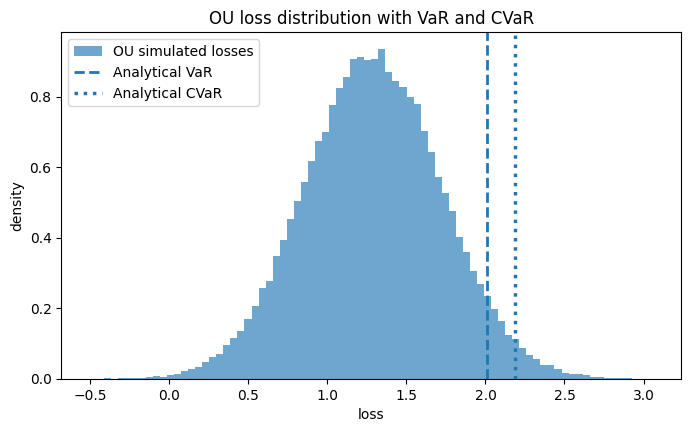

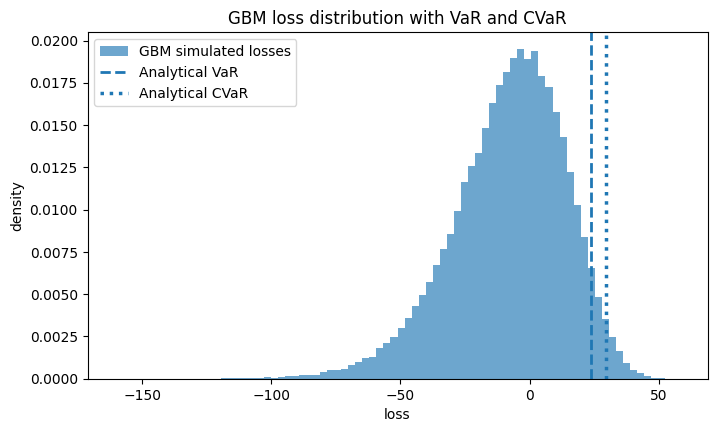

In [12]:
plt.figure(figsize=(8, 4.5))
plt.hist(ou_loss_samples, bins=80, density=True, alpha=0.65, label="OU simulated losses")
plt.axvline(ou_var_exact, linestyle="--", linewidth=2.0, label="Analytical VaR")
plt.axvline(ou_cvar_exact, linestyle=":", linewidth=2.5, label="Analytical CVaR")
plt.xlabel("loss")
plt.ylabel("density")
plt.title("OU loss distribution with VaR and CVaR")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(gbm_loss_samples, bins=80, density=True, alpha=0.65, label="GBM simulated losses")
plt.axvline(gbm_var_exact, linestyle="--", linewidth=2.0, label="Analytical VaR")
plt.axvline(gbm_cvar_exact, linestyle=":", linewidth=2.5, label="Analytical CVaR")
plt.xlabel("loss")
plt.ylabel("density")
plt.title("GBM loss distribution with VaR and CVaR")
plt.legend()
plt.show()

## 5. Summary

This project developed a compact Stochastic Process framework that connects Physics and Finance through Itô SDEs, transition densities, Fokker-Planck PDEs, and Monte Carlo simulation. The starting point was the general one-dimensional Itô SDE

$$
dX_t=a(X_t,t)\,dt+b(X_t,t)\,dW_t.
$$

For this process, Itô's formula explains how smooth functions of $X_t$ evolve, while the forward Fokker-Planck equation describes the evolution of its transition density

$$
p(x,t|x_0,t_0).
$$

The Ornstein-Uhlenbeck process was studied as the canonical linear additive-noise model:

$$
dX_t=-\lambda(X_t-\theta)\,dt+\eta\,dW_t.
$$

Its transition law is Gaussian, with mean-reversion toward $\theta$ and variance controlled by $\eta$ and $\lambda$. This makes it natural both for linear relaxation in physics and for mean-reverting financial quantities. Geometric Brownian Motion was then studied as the canonical linear multiplicative-noise model:

$$
dX_t=\mu X_t\,dt+\sigma X_t\,dW_t.
$$

Its transition law is signed-lognormal for nonzero initial value, and positive lognormal in the standard stock-price case. This makes GBM the natural bridge from stochastic calculus to the Black-Scholes stock-price model. The final application used the transition laws to compute tail-risk measures for the loss

$$
L=S_{t_0}-S_t.
$$

For the OU model, the loss is normal, so VaR and CVaR follow directly from the normal quantile and upper-tail expectation. For the GBM stock-price model, large losses correspond to the lower tail of the lognormal terminal price, giving closed-form formulas for VaR and CVaR. Monte Carlo simulations based on exact terminal sampling were used to check the analytical formulas through Order Statistics. The main conclusion is that once an SDE transition law is known, the same object can be used in several ways: as a probability density solving the Fokker-Planck equation, as a Monte Carlo benchmark, and as an input for financial risk measures such as VaR and CVaR.

## 6. References

1. D. T. Gillespie, “The mathematics of Brownian motion and Johnson noise,” *Am. J. Phys.* **64**, 225 (1996)
2. C. W. Gardiner, *Handbook of Stochastic Methods: for Physics, Chemistry and the Natural Sciences*, Springer
3. MIT OpenCourseWare, *18.642 Topics in Mathematics with Applications in Finance*, Fall 2024, Lecture Notes